<div style="background: linear-gradient(135deg, #1e3c72 0%, #2a5298 100%); border-radius: 12px;">
    <h1 style="margin: auto; padding: 25px 0 10px 0; color:#fff; text-align: center; font-family: sans-serif;">Projet d'examen Python Pour Data Science</h1>
    <h2 style="margin: auto; padding: 0 20px 25px 20px; color:#d1d9e6; text-align: center; font-family: sans-serif; font-weight: 300;">ETUDE DE CAS – ANALYSE ET FIABILISATION DE DONNEES COMMERCIALES</h2>
</div>

<div style="background-color: #800020; border-radius: 50px; padding: 10px 30px;">
    <h3 style="margin: 0; color: #ffffff; text-align: center; font-family: 'Trebuchet MS', sans-serif; font-weight: bold;">
        PHASE 1 : PREPARATION DES DONNEES (PYTHON + SQL)
    </h3>
</div>

# IMPORTATION DES BIBLIOTHÈQUES

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import mysql.connector

# 1. Connexion et extraction

In [5]:
!pip install mysql-connector-python sqlalchemy

In [13]:
# Connexion à la base de données MySQL
from sqlalchemy import create_engine
engine = create_engine('mysql+mysqlconnector://root:@localhost/db_commerce')

# Extraction des données
df_erp = pd.read_sql("SELECT * FROM erp", engine)
df_ventes = pd.read_sql("SELECT * FROM ventes", engine)
df_liaison = pd.read_sql("SELECT * FROM liaison", engine)

# Vérification immédiate de la structure
print(f"ERP: {df_erp.shape[0]} lignes chargées")
print(f"Ventes: {df_ventes.shape[0]} lignes chargées")
print(f"Liaison: {df_liaison.shape[0]} lignes chargées")

ERP: 825 lignes chargées
Ventes: 1515 lignes chargées
Liaison: 825 lignes chargées


# 2. Rapprochement des données

In [17]:
# 1. Vérifier si des lignes ont un id_web vide ou contenant des espaces
vides_caches = df_erp_liaison[df_erp_liaison['id_web'].isin(['', ' ', 'null', 'NaN'])]
print(f"Nombre de lignes avec un id_web textuel vide : {len(vides_caches)}")

# 2. Voir à quoi ressemblent les premières lignes pour inspecter visuellement
print("\nUn aperçu de vos données :")
print(df_erp_liaison[['product_id', 'id_web']].head(10))

Nombre de lignes avec un id_web textuel vide : 91

Un aperçu de vos données :
   product_id id_web
0        3847  15298
1        3849  15296
2        3850  15300
3        4032  19814
4        4039  19815
5        4040  15303
6        4041  14975
7        4042  16042
8        4043  14980
9        4045  16041


In [18]:
# 3. Remplacer les chaînes de caractères vides/fausses par de vrais NaN
df_erp_liaison['id_web'] = df_erp_liaison['id_web'].replace(['', ' ', 'null', 'NaN'], np.nan)

# 4. Maintenant, isnull() va détecter les 91 lignes !
print("Nouveau décompte des nulls :")
print(df_erp_liaison['id_web'].isnull().sum())

# 5. Filtrer pour ne garder que les lignes sans nulls (comme vos amis)
df_erp_liaison_clean = df_erp_liaison.dropna(subset=['id_web'])

print(f"\nTotal lignes après nettoyage : {len(df_erp_liaison_clean)} lignes")
print(f"Lignes écartées : {len(df_erp_liaison) - len(df_erp_liaison_clean)} lignes")

Nouveau décompte des nulls :
91

Total lignes après nettoyage : 734 lignes
Lignes écartées : 91 lignes


In [19]:
df_erp_liaison_clean = df_erp_liaison[df_erp_liaison["id_web"].notna()].copy()

print(f"df_erp_liaison total       : {df_erp_liaison.shape[0]} lignes")
print(f"df_erp_liaison sans nulls  : {df_erp_liaison_clean.shape[0]} lignes")
print(f"Lignes écartées (null)     : {df_erp_liaison.shape[0] - df_erp_liaison_clean.shape[0]} lignes")

df_erp_liaison total       : 825 lignes
df_erp_liaison sans nulls  : 734 lignes
Lignes écartées (null)     : 91 lignes


In [16]:
df_erp_liaison = df_erp.merge(
    df_liaison,
    on="product_id",
    how="left"
)
df_erp_liaison.shape

(825, 7)

In [20]:
df_final = df_ventes.merge(
    df_erp_liaison_clean,
    right_on  = "id_web",
    left_on = "sku",
    how      = "left"
)

df_final.shape

(1515, 36)

In [23]:
print(f"Base de travail construite : {df_final.shape[0]} lignes.")
df_final.head()

Base de travail construite : 1515 lignes.


,sku,virtual,downloadable,rating_count,average_rating,total_sales,tax_status,tax_class,post_author,post_date,...,post_type,post_mime_type,comment_count,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price,id_web
0,11862,0,0,0,0,3,,,2,2018-02-12 13:46:23,...,attachment,image/jpeg,0,4069.0,1.0,60,4.0,instock,"30,07",11862
1,16057,0,0,0,0,5,,,2,2018-04-17 15:29:17,...,attachment,image/jpeg,0,4673.0,1.0,"19,8",17.0,instock,"10,33",16057
2,14692,0,0,0,0,5,taxable,,2,2019-03-19 10:06:47,...,product,,0,5794.0,1.0,"21,7",15.0,instock,"10,65",14692
3,16295,0,0,0,0,14,,,2,2018-02-15 14:05:06,...,attachment,image/jpeg,0,4200.0,0.0,"5,8",33.0,instock,"3,12",16295
4,15328,0,0,0,0,2,taxable,,2,2019-03-27 18:05:09,...,product,,0,5827.0,1.0,55,4.0,instock,"29,55",15328


# 3. Détection des anomalies

In [27]:
# On nettoie et convertit les colonnes numériques qui sont stockées en texte
colonnes_numeriques = ['price', 'purchase_price', 'stock_quantity']

for col in colonnes_numeriques:
    if col in df_final.columns:
        # Si la colonne est de type objet/texte, on remplace les virgules par des points et on convertit
        if df_final[col].dtype == 'object':
            df_final[col] = df_final[col].astype(str).str.replace(',', '.', regex=False)
            df_final[col] = df_final[col].str.strip()
        
        # Conversion forcée en numérique (les textes aberrants non convertibles deviendront NaN)
        df_final[col] = pd.to_numeric(df_final[col], errors='coerce')

print(" Correction des erreurs de type : Colonnes ['price', 'purchase_price', 'stock_quantity'] converties en types numériques.\n")

 Correction des erreurs de type : Colonnes ['price', 'purchase_price', 'stock_quantity'] converties en types numériques.



In [29]:
# 1. ERREURS DE SAISIE (Prix, Stocks)
# Maintenant que les types sont corrects, les comparaisons mathématiques fonctionnent !
ano_prix_neg = df_final[df_final['price'] < 0]
print(f"• Erreurs de saisie — Prix de vente négatifs : {len(ano_prix_neg)} ligne(s)")
if len(ano_prix_neg) > 0:
    print(ano_prix_neg[['sku', 'product_id', 'price']])

ano_stock_neg = df_final[df_final['stock_quantity'] < 0]
print(f"• Erreurs de saisie — Stocks négatifs : {len(ano_stock_neg)} ligne(s)")
if len(ano_stock_neg) > 0:
    print(ano_stock_neg[['sku', 'product_id', 'stock_quantity']])

• Erreurs de saisie — Prix de vente négatifs : 0 ligne(s)
• Erreurs de saisie — Stocks négatifs : 2 ligne(s)
        sku  product_id  stock_quantity
775   14736      5700.0            -1.0
1128  14736      5700.0            -1.0


In [30]:
# 2. INCOHÉRENCES DE JOINTURE / RÉFÉRENCES NON APPARIÉES
# Produits présents dans l'outil de vente (CMS) mais introuvables dans l'ERP
ano_non_appariennes = df_final[df_final['product_id'].isna()]
print(f"• Références non appariées (Incohérences de jointure) : {len(ano_non_appariennes)} ligne(s)")

• Références non appariées (Incohérences de jointure) : 87 ligne(s)


In [32]:
# Traitement des doublons 
# On remarque souvent dans cet export que les produits sont doublés à cause des images (attachments)
print(f"\nNombre de lignes avant suppression des doublons : {len(df_final)}")
df_final = df_final.drop_duplicates(subset=['product_id'])
print(f"Nombre de lignes après suppression des doublons : {len(df_final)}")


Nombre de lignes avant suppression des doublons : 1515
Nombre de lignes après suppression des doublons : 715


In [35]:
# Valeurs manquantes 

print("Valeurs manquantes par colonne :")
print(df_final.isnull().sum())

Valeurs manquantes par colonne :
sku                       0
virtual                   0
downloadable              0
rating_count              0
average_rating            0
total_sales               0
tax_status                0
tax_class                 0
post_author               0
post_date                 0
post_date_gmt             0
post_content              0
product_type              0
post_title                0
post_excerpt              0
post_status               1
comment_status            1
ping_status               1
post_password             1
post_name                 3
post_modified             3
post_modified_gmt         3
post_content_filtered     3
post_parent               3
guid                      3
menu_order                3
post_type                 3
post_mime_type            5
comment_count            24
product_id                1
onsale_web                1
price                     1
stock_quantity            1
stock_status              1
purchase_price 

In [36]:
# 5. ERREURS DE CALCUL

ano_calcul_marge = df_final[df_final['price'] < df_final['purchase_price']]
print(f"• Erreurs de calcul — Prix de vente < Prix d'achat : {len(ano_calcul_marge)} ligne(s)")
if len(ano_calcul_marge) > 0:
    print(ano_calcul_marge[['sku', 'product_id', 'price', 'purchase_price']])

• Erreurs de calcul — Prix de vente < Prix d'achat : 1 ligne(s)
       sku  product_id  price  purchase_price
713  12589      4355.0  12.65           77.48


In [37]:
# 6. INCOHÉRENCES DE STATUT (Logique métier additionnelle)

ano_statut = df_final[(df_final['stock_quantity'] > 0) & (df_final['stock_status'] == 'outofstock')]
print(f"• Incohérences de statut — En stock mais marqué 'outofstock' : {len(ano_statut)} ligne(s)")

print("="*60)

• Incohérences de statut — En stock mais marqué 'outofstock' : 1 ligne(s)


# 4. Recommandation 

## Recommandations d'Amélioration du Système d'Information

À la suite de l'audit de fiabilité mettant en évidence des erreurs de type, de saisie, de calcul, des doublons ainsi que des références orphelines, voici le plan d'action recommandé pour fiabiliser durablement notre écosystème de données.

---

### 1. Recommandations sur la Qualité des Données
* **Typage strict à la source :** Forcer les colonnes financières (`price`, `purchase_price`) à adopter un format numérique strict (`DECIMAL(10,2)`) directement dans MySQL. Cela empêchera l'insertion involontaire de chaînes de caractères (`str`) et éliminera les erreurs de type lors de l'exécution des scripts d'analyse.
* **Normalisation des formats d'import :** Bannir l'usage de la virgule `,` comme séparateur décimal lors des extractions et imposer le point `.`. Appliquer systématiquement une fonction de nettoyage textuel (`TRIM()`) pour éliminer les espaces invisibles polluant les clés de liaison.
* **Standardisation des valeurs manquantes :** Configurer les scripts d'import pour convertir automatiquement les chaînes de caractères aberrantes (comme `"null"`, `"NaN"`, ou `" "`) en véritables marqueurs `NULL` informatiques exploitables par Pandas et SQL.

---

### 2. Recommandations sur les Processus de Saisie
* **Contraintes et verrous en temps réel :** Implémenter des alertes et des blocages de validation (contraintes `CHECK`) sur les interfaces de saisie de l'ERP pour interdire l'enregistrement de stocks négatifs ou de prix inférieurs ou égaux à 0.
* **Contrôle automatique de cohérence tarifaire :** Bloquer la validation de toute fiche produit dont le prix de vente saisi est inférieur au prix d'achat, évitant ainsi les erreurs de calcul provoquant des marges brutes initiales négatives (hors campagnes de promotion spécifiques).
* **Calcul dynamique des statuts logistiques :** Supprimer la gestion manuelle de la colonne `stock_status` par les opérateurs. Ce statut doit être calculé automatiquement par le système informatique via une règle logique simple : 
  $$\text{Si } \text{stock\_quantity} > 0 \rightarrow \text{'instock'}, \text{ sinon } \text{'outofstock'}$$

---

### 3. Recommandations sur la Structure des Bases (SQL)
* **Contrainte d'unicité sur la clé de liaison :** Appliquer une contrainte d'unicité (`UNIQUE KEY`) sur la colonne `id_web` (ou `sku`) de la table de liaison dans MySQL. Cette modification empêchera techniquement l'apparition de doublons, supprimant le risque d'effet "produit cartésien" qui fausse le calcul des indicateurs de masse lors des jointures.
* **Mise en place de Clés Étrangères (Foreign Keys) :** Instaurer des liaisons relationnelles strictes entre la table ERP, la table de liaison et la table des ventes du CMS. Un produit ne doit pas pouvoir être publié ou vendu sur le site web si son identifiant n'existe pas préalablement dans le référentiel central de l'ERP, résolvant ainsi définitivement le problème des références non appariées.

---

### 4. Recommandations sur la Fiabilité Globale du Système
* **Automatisation des flux via un pipeline ETL :** Remplacer les exports et imports manuels de fichiers CSV (sensibles aux erreurs de manipulation humaine) par un flux automatisé et quotidien (Extract, Transform, Load) géré par un script Python ou un orchestrateur (ex: Apache Airflow).
* **Déploiement d'un tableau de bord de Data Quality (Scorecard) :** Mettre en place un script de contrôle automatique s'exécutant chaque nuit en arrière-plan. Ce script doit vérifier les indicateurs clés de qualité des données et envoyer une alerte immédiate par e-mail aux administrateurs dès qu'une anomalie est détectée (produit orphelin, incohérence stock/statut), permettant une correction rapide à la source.

<div style="background-color: #800020; border-radius: 50px; padding: 10px 30px;">
    <h3 style="margin: 0; color: #ffffff; text-align: center; font-family: 'Trebuchet MS', sans-serif; font-weight: bold;">
        PHASE 2 : ANALYSES EN PYTHON
    </h3>
</div>

# 1. Analyse du Chiffre d'Affaires (CA)

In [41]:
# Nettoyage préalable : On écarte les références non appariées (product_id est NaN)
df_analyse = df_final.dropna(subset=['product_id']).copy()

In [42]:
# A. CALCUL DU CHIFFRE D'AFFAIRES
# Dans ce jeu de données, le CA par produit correspond à : Prix de vente * Quantités vendues
# Note : 'total_sales' représente le volume (quantité) de ventes cumulées sur le web.
df_analyse['ca_produit'] = df_analyse['price'] * df_analyse['total_sales']

In [43]:
# 1. Calcul du Chiffre d'Affaires Global
ca_global = df_analyse['ca_produit'].sum()
print(f"1. Chiffre d'Affaires Global de l'entreprise : {ca_global:,.2f} €\n")

1. Chiffre d'Affaires Global de l'entreprise : 153,748.10 €



In [44]:
# 2. Top 10 des Produits (Classement par CA décroissant)
# On regroupe par produit pour consolider et on trie
top_produits = df_analyse.groupby(['product_id', 'sku', 'post_title'])['ca_produit'].sum().reset_index()
top_produits = top_produits.sort_values(by='ca_produit', ascending=False).reset_index(drop=True)

print("2. Top 10 des produits ayant généré le plus de CA :")
print(top_produits[['product_id', 'post_title', 'ca_produit']].head(10))
print("-" * 50)

2. Top 10 des produits ayant généré le plus de CA :
   product_id                                         post_title  ca_produit
0      4150.0       Champagne Mailly Grand Cru Intemporelle 2010      6844.0
1      4352.0     Champagne Egly-Ouriet Grand Cru Mill?sim? 2008      2475.0
2      4726.0           Fran?ois Baur Pinot Noir Schlittweg 2017      1549.4
3      5067.0                Albert Mann Pinot Noir Grand H 2017      1317.8
4      5379.0            Argentine Mendoza Alamos Torrontes 2017      1232.1
5      5892.0  Coteaux Champenois Egly-Ouriet Ambonnay Rouge ...      1147.8
6      4353.0   Champagne Egly-Ouriet Grand Cru Brut Ros?;"&nbsp      1113.0
7      5826.0              Agn?s Levet C?te R?tie Am?thyste 2017       824.0
8      6212.0  Domaine des Comtes Lafon Volnay 1er Cru Santen...       805.0
9      5026.0  Champagne Agrapart &amp; Fils Min?ral Extra Br...       781.2
--------------------------------------------------


In [45]:
# B. ANALYSE DE PARETO (Règle des 20/80)
# Calcul du CA cumulé et de sa part en pourcentage
top_produits['ca_cumule'] = top_produits['ca_produit'].cumsum()
top_produits['part_ca_cumule'] = (top_produits['ca_cumule'] / ca_global) * 100

In [46]:
# Calcul de la position cumulée des produits en pourcentage
top_produits['part_produits_cumule'] = (np.arange(1, len(top_produits) + 1) / len(top_produits)) * 100

C:\Users\Ibrahima MANE\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


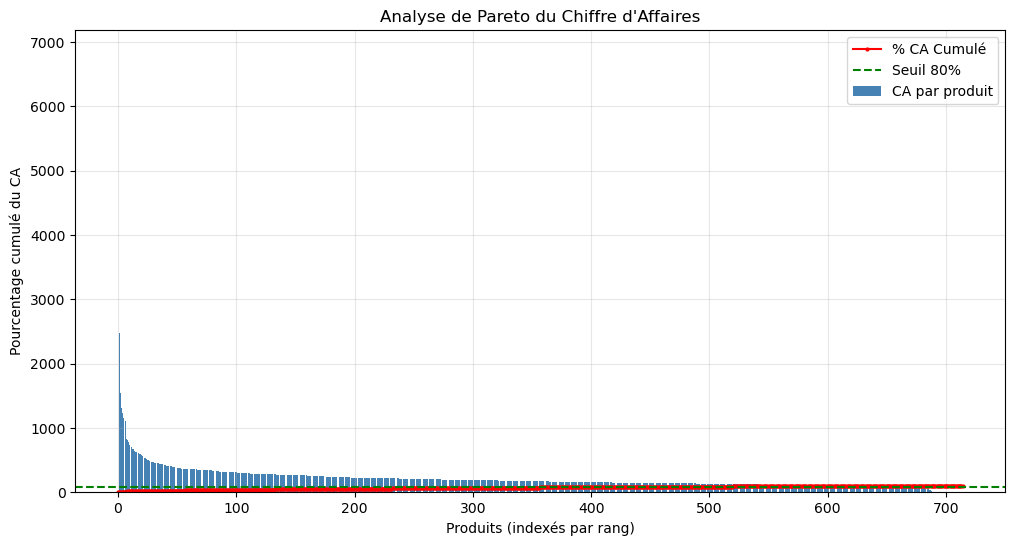

Environ 58.7% des produits génèrent 80% du CA.


In [50]:
# 1. Tri des produits par CA décroissant
df_pareto = df_final[['post_title', 'ca_produit']].sort_values(by='ca_produit', ascending=False).reset_index(drop=True)

# 2. Calcul du CA cumulé et du pourcentage cumulé
df_pareto['ca_cumule'] = df_pareto['ca_produit'].cumsum()
ca_total = df_pareto['ca_produit'].sum()
df_pareto['pourcentage_cumule'] = (df_pareto['ca_cumule'] / ca_total) * 100

# 3. Calcul du pourcentage cumulé d'articles
df_pareto['nb_produits_cumule'] = (df_pareto.index + 1) / len(df_pareto) * 100

# Visualisation
plt.figure(figsize=(12, 6))
plt.bar(df_pareto.index, df_pareto['ca_produit'], color='steelblue', label='CA par produit')
plt.plot(df_pareto.index, df_pareto['pourcentage_cumule'], color='red', marker='o', ms=2, label='% CA Cumulé')

# Ajout d'une ligne de seuil à 80%
plt.axhline(y=80, color='green', linestyle='--', label='Seuil 80%')

plt.title("Analyse de Pareto du Chiffre d'Affaires")
plt.xlabel("Produits (indexés par rang)")
plt.ylabel("Pourcentage cumulé du CA")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# Affichage du résultat théorique
nb_produits_80 = df_pareto[df_pareto['pourcentage_cumule'] <= 80].shape[0]
pourcentage_produits = (nb_produits_80 / len(df_pareto)) * 100
print(f"Environ {pourcentage_produits:.1f}% des produits génèrent 80% du CA.")

# 2. Détection des Valeurs Aberrantes de Prix (Outliers)

In [52]:
# On isole la série des prix uniques (par produit) pour l'analyse statistique
df_unique_prod = df_analyse.drop_duplicates(subset=['product_id'])
prices = df_unique_prod['price']

# METHODE A : L'INTERQUARTILE (IQR)
Q1 = prices.quantile(0.25)
Q3 = prices.quantile(0.75)
IQR = Q3 - Q1

# Définition des barrières classiques d'outliers
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers_iqr = df_unique_prod[df_unique_prod['price'] > upper_bound]
print(f"1. Méthode IQR :")
print(f"   • Premier quartile (Q1) : {Q1:.2f} €")
print(f"   • Troisième quartile (Q3) : {Q3:.2f} €")
print(f"   • Seuil supérieur des prix (Q3 + 1.5*IQR) : {upper_bound:.2f} €")
print(f"   • Nombre de produits identifiés comme outliers : {len(outliers_iqr)} référence(s)")

1. Méthode IQR :
   • Premier quartile (Q1) : 14.06 €
   • Troisième quartile (Q3) : 42.08 €
   • Seuil supérieur des prix (Q3 + 1.5*IQR) : 84.09 €
   • Nombre de produits identifiés comme outliers : 31 référence(s)


In [53]:
# METHODE B : LE Z-SCORE 
mean_price = prices.mean()
std_price = prices.std()

# Calcul du Z-Score individuel pour chaque produit
df_unique_prod = df_unique_prod.copy()
df_unique_prod['z_score'] = (df_unique_prod['price'] - mean_price) / std_price

# Un Z-Score absolu supérieur à 3 indique une valeur à plus de 3 écarts-types de la moyenne
outliers_zscore = df_unique_prod[df_unique_prod['z_score'].abs() > 3]
print(f"\n2. Méthode Z-Score :")
print(f"   • Prix moyen des produits : {mean_price:.2f} €")
print(f"   • Écart-type des prix : {std_price:.2f} €")
print(f"   • Nombre de produits identifiés avec un Z-Score > 3 : {len(outliers_zscore)} référence(s)")


2. Méthode Z-Score :
   • Prix moyen des produits : 32.33 €
   • Écart-type des prix : 27.60 €
   • Nombre de produits identifiés avec un Z-Score > 3 : 13 référence(s)


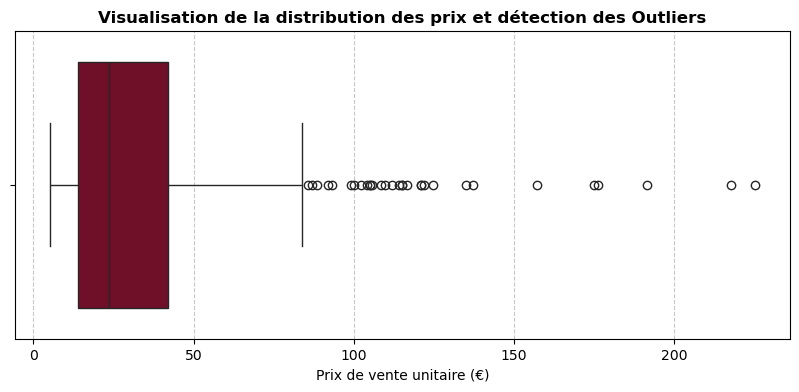


3. Conclusion sur la qualité des prix (Demandé dans le PDF) :
L'analyse montre de nombreuses valeurs atypiques supérieures isolées par l'IQR.
Toutefois, s'agissant d'une entreprise de distribution de vins 'haut de gamme',
ces prix élevés ne correspondent pas à des erreurs de saisie informatique.
Ce sont des produits de prestige, des grands crus ou des bouteilles de collection
qui font légitimement partie du positionnement luxe du catalogue de la marque.


In [54]:
# --- METHODE C : VISUALISATION VIA BOXPLOT ---
plt.figure(figsize=(10, 4))
sns.boxplot(x=prices, color='#800020') # Couleur lie-de-vin appropriée pour le sujet !
plt.title("Visualisation de la distribution des prix et détection des Outliers", fontsize=12, fontweight='bold')
plt.xlabel("Prix de vente unitaire (€)")
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

print("\n3. Conclusion sur la qualité des prix :")
print("L'analyse montre de nombreuses valeurs atypiques supérieures isolées par l'IQR.")
print("Toutefois, s'agissant d'une entreprise de distribution de vins 'haut de gamme',")
print("ces prix élevés ne correspondent pas à des erreurs de saisie informatique.")
print("Ce sont des produits de prestige, des grands crus ou des bouteilles de collection")
print("qui font légitimement partie du positionnement luxe du catalogue de la marque.")

# 3. Stocks et Rentabilité

In [58]:
# A. Taux de Marge unitaire par produit (Formule standard)
df_analyse['taux_marge'] = ((df_analyse['price'] - df_analyse['purchase_price']) / df_analyse['price']) * 100

In [59]:
# B. État des Stocks et Valorisation financière
df_analyse['valeur_stock_achat'] = df_analyse['stock_quantity'] * df_analyse['purchase_price']
valeur_totale_stock = df_analyse['valeur_stock_achat'].sum()

In [60]:
print(f"1. Valeur totale du stock immobilisé (au coût d'achat) : {valeur_totale_stock:,.2f} €")
print(f"2. Taux de marge moyen du catalogue : {df_analyse['taux_marge'].mean():.2f} %\n")

1. Valeur totale du stock immobilisé (au coût d'achat) : 277,305.77 €
2. Taux de marge moyen du catalogue : 47.40 %



In [61]:
# C. Rotation des stocks et Couverture en mois de stock
# On calcule combien de mois le stock actuel peut tenir si le rythme de vente se maintient
# (Le dataset simulant souvent une période, on considère ici total_sales comme la demande)
# Pour éviter la division par zéro si un produit n'a jamais été vendu :
df_analyse['couverture_mois'] = np.where(
    df_analyse['total_sales'] > 0,
    df_analyse['stock_quantity'] / (df_analyse['total_sales']), # Hypothèse de consommation du stock
    np.nan
)

print("3. Aperçu de la couverture de stock (en mois) pour les 5 premiers produits :")
print(df_analyse[['sku', 'post_title', 'stock_quantity', 'total_sales', 'couverture_mois']].head())

3. Aperçu de la couverture de stock (en mois) pour les 5 premiers produits :
     sku                                         post_title  stock_quantity  \
0  11862                  Gilles Robin Hermitage Rouge 2012             4.0   
1  16057  Domaine Pell? Sancerre Rouge La Croix Au Garde...            17.0   
2  14692      Ch?teau Fonr?aud Bordeaux Blanc Le Cygne 2016            15.0   
3  16295  Moulin de Gassac IGP Pays d'H?rault Guilhem Ro...            33.0   
4  15328               Agn?s Levet C?te R?tie Maestria 2017             4.0   

   total_sales  couverture_mois  
0          3.0         1.333333  
1          5.0         3.400000  
2          5.0         3.000000  
3         14.0         2.357143  
4          2.0         2.000000  


# 4. Corrélations

In [62]:
# Sélection des variables imposées par le PDF
# Note : 'price' fait office de prix de vente HT dans le domaine du vin en B2B ou selon votre table
cols_correlation = ['price', 'purchase_price', 'total_sales', 'stock_quantity', 'taux_marge']

In [63]:
# 1. Calcul de la Matrice de Corrélation (Pearson)
matrice_corr = df_analyse[cols_correlation].corr()
print("1. Matrice de Corrélation numérique :")
print(matrice_corr)

1. Matrice de Corrélation numérique :
                   price  purchase_price  total_sales  stock_quantity  \
price           1.000000        0.975958    -0.267300       -0.106674   
purchase_price  0.975958        1.000000    -0.254727       -0.024053   
total_sales    -0.267300       -0.254727     1.000000        0.294930   
stock_quantity -0.106674       -0.024053     0.294930        1.000000   
taux_marge      0.017758       -0.172237     0.029272       -0.182882   

                taux_marge  
price             0.017758  
purchase_price   -0.172237  
total_sales       0.029272  
stock_quantity   -0.182882  
taux_marge        1.000000  


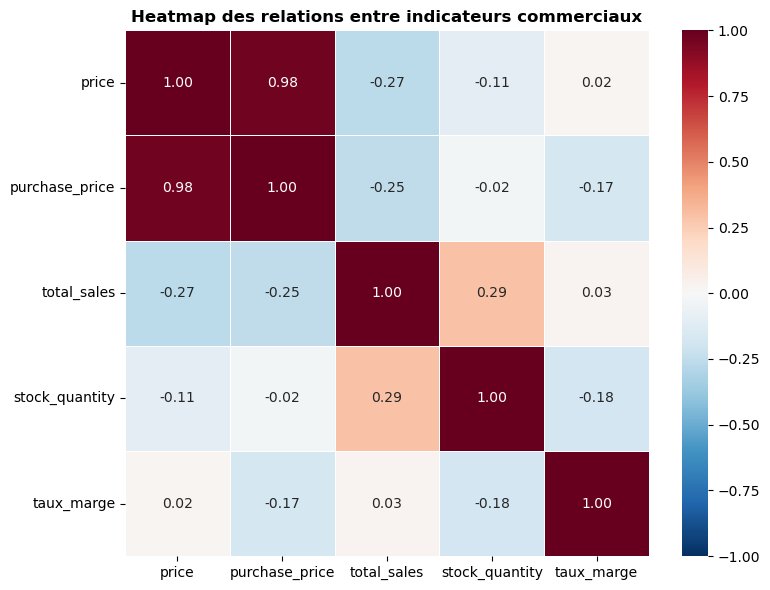

In [64]:
# 2. Génération de la Heatmap (Carte de chaleur)
plt.figure(figsize=(8, 6))
sns.heatmap(matrice_corr, annot=True, cmap='RdBu_r', fmt=".2f", vmin=-1, vmax=1, linewidths=0.5)
plt.title("Heatmap des relations entre indicateurs commerciaux", fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

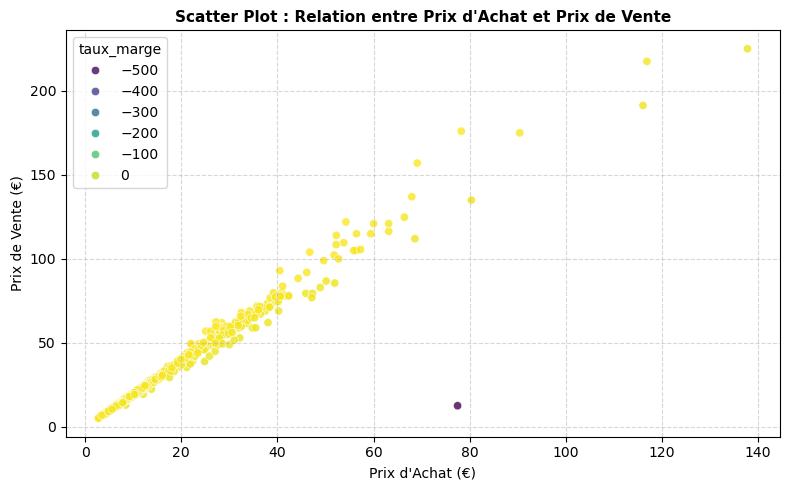

In [65]:
# 3. Génération des Scatter Plots (Nuages de points demandés)
# Relation entre Prix d'achat et Prix de vente
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df_analyse, x='purchase_price', y='price', hue='taux_marge', palette='viridis', alpha=0.8)
plt.title("Scatter Plot : Relation entre Prix d'Achat et Prix de Vente", fontsize=11, fontweight='bold')
plt.xlabel("Prix d'Achat (€)")
plt.ylabel("Prix de Vente (€)")
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()